# 🔬 BioSLATE Phase 2B — Multi-Modal Validation of Synthetic Lethal Targets (HGSOC)

**Author:** Faith Ogundimu  
**Date:** August 8th 2025

## Notebook Purpose
To validate context-specific synthetic lethal (SL) dependencies identified in Phase 3 through orthogonal multi-modal analysis, testing whether CNA-driven vulnerabilities replicate across DNA and RNA molecular layers.

## Validation Strategy: Same Biology, Different Measurements

### The Core Question
**Does CNA amplification drive synthetic lethality through increased gene expression, or via other DNA-level mechanisms?**

### Multi-Modal Approach
Rather than running two separate screens, we perform **one biological experiment with two molecular readouts**:

1. **Primary Screen (DNA level)**: Identify synthetic lethal pairs using CNA amplification status
2. **Orthogonal Validation (RNA level)**: Test whether the *same CNA-amplified samples* show vulnerability when measured through expression data

### Key Methodological Innovation
**Previous approaches** (Phase 3A): 
- CNA screen: samples defined by CNA ≥ 6 vs CNA = 2
- Expression screen: samples defined by expression percentiles (80th vs median)
- *Different sample groups = not truly orthogonal*

**Phase 3B approach**:
- CNA screen: samples defined by CNA ≥ 6 vs CNA = 2  
- Expression validation: *exact same CNA ≥ 6 samples* tested using their expression values
- *Same sample groups = true orthogonal validation*

## Biological Rationale

### DNA → RNA → Protein → Function Pipeline
```
CNA amplification (DNA) → Increased transcription (RNA) → Higher protein levels → Synthetic lethality
```

### Validation Logic
- **High validation rate**: CNA effects likely work through expression-mediated mechanisms
- **Low validation rate**: CNA effects work through non-transcriptional mechanisms (chromatin structure, replication stress, etc.)

## Technical Implementation

### Unified Analysis Framework
1. **Sample Selection**: Identify cell lines with all three data types (CNA, expression, CRISPR)
2. **Group Definition**: Use CNA ≥ 6 to define "high" group across both analyses
3. **Dual Regression**: 
   - `Dependency ~ CNA_value` (primary)
   - `Dependency ~ Expression_value` (validation, same samples)
4. **Validation Metrics**: Compare effect sizes, significance, and replication rates

### Expected Outcomes
- **Validated pairs**: Significant in both CNA and expression analyses
- **Validation rate**: Proportion of CNA hits that replicate in expression
- **Effect correlation**: Relationship between CNA and expression effect sizes

## Step 1A: Load Files and Process as Necessary Screening Configurations

In [4]:
# Required packages
import pandas as pd
import numpy as np

# Load input datasets:
## AMP biomarkers
amp_biomarkers = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cross_val_amp_sig_genes.csv", index_col=1)
amp_biomarkers = amp_biomarkers.index.astype(str)
amp_biomarkers

## CNA DepMap for AMP screen
cna_hgsoc_depmap = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cna_depmap_hgsoc.csv", index_col=0)
cna_hgsoc_depmap = cna_hgsoc_depmap.transpose()
cna_hgsoc_depmap_filtered_amp = cna_hgsoc_depmap.loc[amp_biomarkers]
cna_hgsoc_depmap_filtered_amp = cna_hgsoc_depmap_filtered_amp.transpose()

## CRISPR
crispr_filtered = pd.read_csv("../results/crispr_hgsoc.csv", index_col=0) 

### Expression Replicate: Rerun OLS using Biomarker RNA-Seq Expression to Confirm CNA Effects aren’t Artefacts

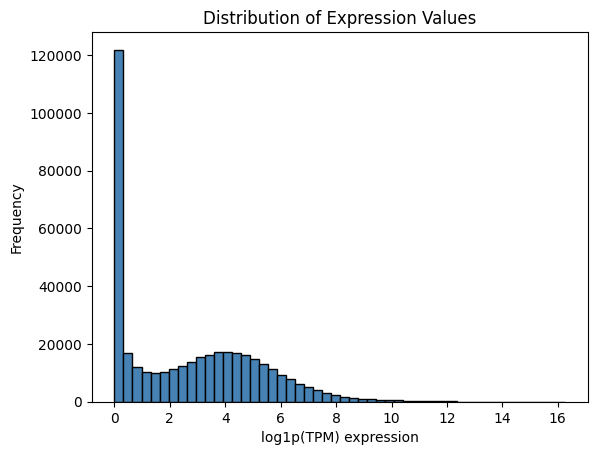

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your expression matrix
expr_hist = pd.read_csv("../results/expression_hgsoc.csv", index_col=0) 

# Flatten to a 1D array for distribution
all_values = expr_hist.values.flatten()

plt.hist(all_values, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("log1p(TPM) expression")
plt.ylabel("Frequency")
plt.title("Distribution of Expression Values")
plt.show()

In [ ]:
import pandas as pd

# Load expression file
expr_df = pd.read_csv("../results/expression_hgsoc.csv", index_col=0)

# Load HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build reverse mapping: HGNC symbol → Entrez ID (as string)
symbol_to_entrez = dict(zip(hgnc_df["symbol"], hgnc_df["entrez_id"].astype(str)))

# Map expression file columns to Entrez IDs where possible
expr_df.columns = [
    symbol_to_entrez.get(col, col) for col in expr_df.columns
]

# Save updated expression file
expr_df.to_csv("../results/expression_hgsoc_entrez.csv")

print("Updated expression file saved with Entrez IDs for matching.")

In [5]:
expr_df = pd.read_csv("../results/expression_hgsoc_entrez.csv", index_col=0) 
expr_df = expr_df.transpose()
expr_df_filtered_amp = expr_df.loc[amp_biomarkers]
expr_df_filtered_amp = expr_df_filtered_amp.transpose()

expr_df_filtered_amp

Gene,10016,1004,10051,10054,10059,10139,10195,10298,10397,10404,...,9601,96764,9684,9718,9757,9777,9791,9846,9847,9885
ACH-000132,6.471379,5.813332,7.755241,7.238023,5.466924,5.014641,5.876659,4.053311,4.799098,4.245640,...,6.218777,3.704064,5.123650,0.000000,3.498123,4.818523,6.002995,3.763794,4.552943,5.416326
ACH-001151,7.247253,1.197828,7.656175,6.918148,4.915258,4.547289,6.212851,4.795964,5.281027,3.140633,...,7.784203,4.056462,4.675443,0.008249,3.257738,5.935679,6.441960,1.797191,3.535406,4.484924
ACH-000635,6.731903,6.615324,7.604538,7.590624,5.730735,4.320427,6.729580,6.262099,7.653010,3.770026,...,7.019302,3.609861,5.406292,0.009013,4.257682,5.737400,7.129128,3.706166,4.411901,4.498487
ACH-000430,7.108221,0.035185,8.029867,6.954150,5.695852,4.841319,6.555394,4.411460,0.650813,0.077188,...,8.361400,4.533532,4.403268,0.007559,3.679626,5.666214,7.204806,2.578393,3.599425,3.965572
ACH-000103,7.164806,7.432325,6.520653,6.805860,6.181705,5.068740,6.081037,5.531266,4.118601,2.391391,...,7.089043,2.951804,4.540188,0.000000,4.537048,5.872408,5.511598,3.137381,4.625241,5.902069
ACH-000001,7.203671,8.840960,8.467247,8.442214,6.763106,5.079395,6.528412,7.144475,5.889284,3.371379,...,7.412621,4.846403,4.251037,0.219547,4.676363,5.642043,6.687467,5.368751,4.913622,5.352847
ACH-000256,6.293926,4.801469,6.803188,7.173647,5.072886,4.577302,5.608913,4.571859,1.613617,2.332926,...,7.130869,2.703118,2.574029,0.014585,4.003278,5.610434,4.062536,3.474047,3.326058,4.546641
ACH-000542,6.416323,0.138955,8.557544,7.692643,6.856762,4.552980,5.905438,4.486277,4.789614,2.866564,...,5.449185,5.399680,3.952408,0.000000,2.105876,4.610623,7.419926,2.912594,5.819729,3.816456
ACH-000409,7.429164,7.122559,8.112210,7.265774,6.309480,5.572774,7.323910,5.126866,5.716434,3.167127,...,8.188070,3.153332,5.150442,0.088617,3.619436,6.495941,6.468111,3.111894,4.414183,5.058550
ACH-000696,6.187425,0.042210,7.818525,7.197482,6.052811,4.795086,5.127996,5.413702,5.940317,2.894032,...,6.498034,4.336598,5.460186,0.000000,3.526407,5.405414,7.033489,2.683928,4.380639,4.362715


In [ ]:
# Check sample overlap
cna_samples = set(cna_hgsoc_depmap_filtered_amp.index)
expr_samples = set(expr_df_filtered_amp.index)
crispr_samples = set(crispr_filtered.index)

print(f"CNA samples: {len(cna_samples)}")
print(f"Expression samples: {len(expr_samples)}")
print(f"CRISPR samples: {len(crispr_samples)}")
print(f"All three overlap: {len(cna_samples & expr_samples & crispr_samples)}")
print(f"CNA-Expression overlap: {len(cna_samples & expr_samples)}")

CNA samples: 21
Expression samples: 21
CRISPR samples: 18
All three overlap: 15
CNA-Expression overlap: 19


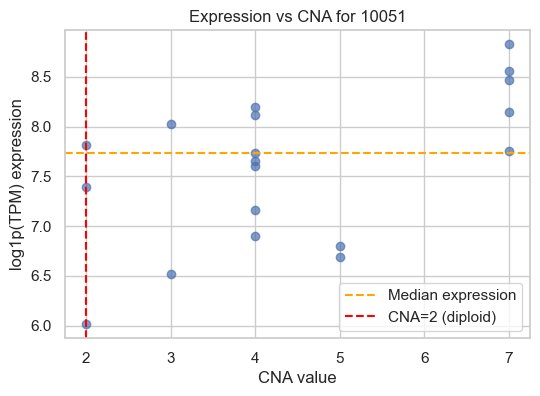

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example biomarker Entrez ID
biomarker_id = "10051" 

# Get overlapping cell lines
common_lines = expr_df_filtered_amp.index.intersection(cna_hgsoc_depmap_filtered_amp.index)

# Extract values
expr_vals = expr_df_filtered_amp.loc[common_lines, biomarker_id]
cna_vals = cna_hgsoc_depmap_filtered_amp.loc[common_lines, biomarker_id]

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(cna_vals, expr_vals, alpha=0.7)
plt.axhline(expr_vals.median(), color="orange", linestyle="--", label="Median expression")
plt.axvline(2, color="red", linestyle="--", label="CNA=2 (diploid)")
plt.xlabel("CNA value")
plt.ylabel("log1p(TPM) expression")
plt.title(f"Expression vs CNA for {biomarker_id}")
plt.legend()
plt.show()

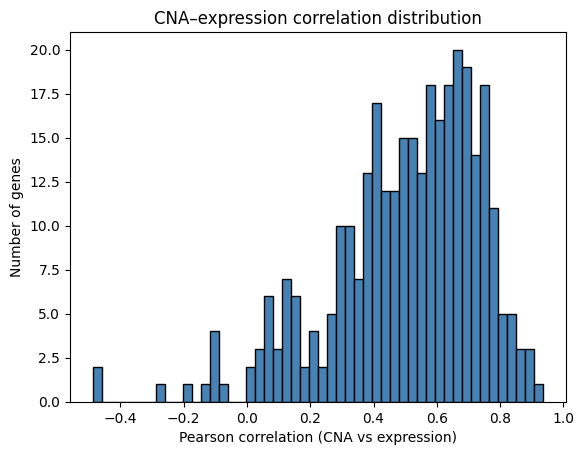

In [ ]:
import pandas as pd

# Ensure both CNA and expression DataFrames have the same gene columns
common_genes = cna_hgsoc_depmap_filtered_amp.columns.intersection(expr_df_filtered_amp.columns)

# Find common cell lines
common_lines = expr_df_filtered_amp.index.intersection(cna_hgsoc_depmap_filtered_amp.index)

# Slice both datasets to the same shape
cna_common = cna_hgsoc_depmap_filtered_amp.loc[common_lines, common_genes]
expr_common = expr_df_filtered_amp.loc[common_lines, common_genes]

# Compute Pearson correlations for each gene
correlations = {}
for gene in common_genes:
    correlations[gene] = cna_common[gene].corr(expr_common[gene])

corr_series = pd.Series(correlations, name="CNA_expr_corr").sort_values(ascending=False)

# Optional: visualise distribution
import matplotlib.pyplot as plt
plt.hist(corr_series, bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Pearson correlation (CNA vs expression)")
plt.ylabel("Number of genes")
plt.title("CNA–expression correlation distribution")
plt.show()

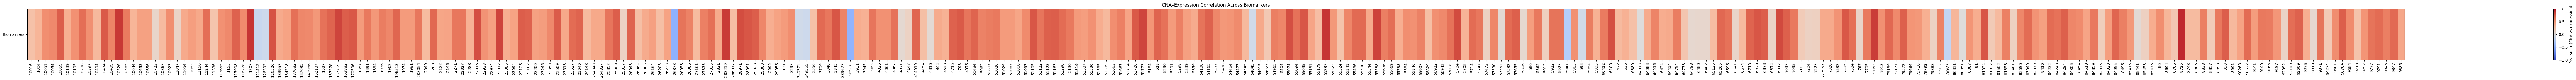

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the rows are the same cell lines in the same order
common_lines = expr_df_filtered_amp.index.intersection(cna_hgsoc_depmap_filtered_amp.index)
expr = expr_df_filtered_amp.loc[common_lines]
cna  = cna_hgsoc_depmap_filtered_amp.loc[common_lines]

# Ensure the same biomarker order in both
common_genes = expr.columns.intersection(cna.columns)
expr = expr[common_genes]
cna  = cna[common_genes]

# Compute Pearson r for each gene
corr_values = [
    np.corrcoef(cna[g], expr[g])[0, 1] for g in common_genes
]
corr_series = pd.Series(corr_values, index=common_genes, name="Pearson_r")

# Plot as heatmap (1 row, N genes)
plt.figure(figsize=(len(common_genes)/3, 3))
plt.imshow(corr_series.values.reshape(1, -1), aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Pearson r (CNA vs expression)')
plt.yticks([0], ["Biomarkers"])
plt.xticks(range(len(common_genes)), common_genes, rotation=90)
plt.title('CNA–Expression Correlation Across Biomarkers')
plt.tight_layout()
plt.show()

# Use VSCode Plots function to zoom in.

### Set Up Config

In [19]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

def run_unified_sl_screen(config, biomarkers, cna_df, expr_df, crispr_df, out_root="../results"):
    """
    Synthetic lethality pipeline:
      1) Discovery on CNA (one-sided FDR, negative direction only)
      2) Validation on expression (nominal one-sided, same direction, effect floor)
    """
    name = config["name"]

    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "validation"), exist_ok=True)

    # Triple-overlap samples (strict). If you want more power, loosen this intentionally.
    common_samples = list(set(cna_df.index) & set(expr_df.index) & set(crispr_df.index))
    print(f"Using {len(common_samples)} samples with all three data types")
    if len(common_samples) < 10:
        print("Warning: very few samples for validation analysis")

    # Subset all matrices
    cna_subset = cna_df.loc[common_samples]
    expr_subset = expr_df.loc[common_samples]
    crispr_subset = crispr_df.loc[common_samples]

    # Biomarkers present in both CNA and expression
    valid_biomarkers = set(biomarkers) & set(cna_subset.columns) & set(expr_subset.columns)

    results_cna = []
    results_expr = []

    for biomarker in valid_biomarkers:
        cna_vector = cna_subset[biomarker].dropna()
        expr_vector = expr_subset[biomarker].dropna()

        # Samples with this biomarker measured in CNA+expr and CRISPR available
        biomarker_samples = cna_vector.index.intersection(expr_vector.index)
        biomarker_samples = biomarker_samples.intersection(crispr_subset.index)
        if len(biomarker_samples) < 6:
            continue

        # CNA-defined groups
        cna_values = cna_vector.loc[biomarker_samples]
        high_cna_samples = cna_values[cna_values >= 6].index  # amp group
        baseline_samples = cna_values[cna_values == 2].index  # baseline
        if len(high_cna_samples) < 2 or len(baseline_samples) < 2:
            continue

        for target in crispr_subset.columns:
            dep_vector = crispr_subset[target].loc[biomarker_samples].dropna()
            final_samples = dep_vector.index.intersection(biomarker_samples)

            if len(final_samples) < 6:
                continue
            if not (dep_vector.loc[final_samples] < -0.6).any():
                continue

            # ------------------
            # CNA model (discovery)
            # ------------------
            try:
                X_cna = sm.add_constant(cna_values.loc[final_samples])
                y = dep_vector.loc[final_samples]
                model_cna = sm.OLS(y, X_cna).fit(cov_type="HC3")

                beta_cna = model_cna.params.iloc[1]
                p_two_cna = model_cna.pvalues.iloc[1]
                y_sd = y.std(ddof=1)
                eff_cna = beta_cna / y_sd if y_sd > 0 else np.nan

                high_cna_in_final = high_cna_samples.intersection(final_samples)
                mean_effect_cna_high = y.loc[high_cna_in_final].mean() if len(high_cna_in_final) > 0 else np.nan
                predicted_at_cna2 = model_cna.predict([1, 2])[0]
                delta_cna = mean_effect_cna_high - predicted_at_cna2 if pd.notnull(mean_effect_cna_high) else np.nan

                results_cna.append({
                    "Biomarker": biomarker,
                    "TargetGene": target,
                    "Beta": beta_cna,
                    "P_two": p_two_cna,                 # two-sided (for record)
                    "EffectSize": eff_cna,
                    "n_Lines": len(final_samples),
                    "n_High_Group": len(high_cna_in_final),
                    "MeanEffect_High": mean_effect_cna_high,
                    "PredictedEffect_Baseline": predicted_at_cna2,
                    "Delta_High_minus_Baseline": delta_cna
                })
            except Exception:
                continue

            # ------------------
            # Expression model (validation)
            # ------------------
            try:
                expr_values = expr_vector.loc[final_samples]
                X_expr = sm.add_constant(expr_values)
                model_expr = sm.OLS(y, X_expr).fit(cov_type="HC3")

                beta_expr = model_expr.params.iloc[1]
                p_two_expr = model_expr.pvalues.iloc[1]
                y_sd_expr = y.std(ddof=1)
                eff_expr = beta_expr / y_sd_expr if y_sd_expr > 0 else np.nan

                mean_effect_expr_in_cna_high = y.loc[high_cna_in_final].mean() if len(high_cna_in_final) > 0 else np.nan
                baseline_in_final = baseline_samples.intersection(final_samples)
                mean_expr_baseline = expr_values.loc[baseline_in_final].mean() if len(baseline_in_final) > 0 else expr_values.median()
                predicted_at_baseline_expr = model_expr.predict([1, mean_expr_baseline])[0]
                delta_expr = mean_effect_expr_in_cna_high - predicted_at_baseline_expr if pd.notnull(mean_effect_expr_in_cna_high) else np.nan

                # store one-sided p for expression (negative direction)
                p_one_expr = (p_two_expr / 2.0) if (beta_expr < 0) else 1.0

                results_expr.append({
                    "Biomarker": biomarker,
                    "TargetGene": target,
                    "Beta": beta_expr,
                    "P_two": p_two_expr,                # two-sided (for record)
                    "P_one": p_one_expr,                # one-sided (used for validation)
                    "EffectSize": eff_expr,
                    "n_Lines": len(final_samples),
                    "n_High_Group": len(high_cna_in_final),
                    "MeanEffect_High": mean_effect_expr_in_cna_high,
                    "PredictedEffect_Baseline": predicted_at_baseline_expr,
                    "Delta_High_minus_Baseline": delta_expr
                })
            except Exception:
                continue

    # DataFrames
    results_cna_df = pd.DataFrame(results_cna)
    results_expr_df = pd.DataFrame(results_expr)

    if results_cna_df.empty or results_expr_df.empty:
        print("No results to validate.")
        return {"ConfigName": name, "Error": "No results"}

    # ----------------------------
    # ONE-SIDED FDR on CNA (β < 0)
    # ----------------------------
    p_two = results_cna_df["P_two"].values
    beta = results_cna_df["Beta"].values
    p_one = np.where(beta < 0, p_two / 2.0, 1.0)

    results_cna_df["P_one_CNA"] = p_one
    results_cna_df["Q_discovery"] = multipletests(
        np.nan_to_num(results_cna_df["P_one_CNA"].values, nan=1.0),
        method="fdr_bh"
    )[1]

    # Save raw screens AFTER adding one-sided columns
    results_cna_df.to_csv(f"{out_dir}/cna_screen_unified.csv", index=False)
    results_expr_df.to_csv(f"{out_dir}/expression_screen_unified.csv", index=False)

    # Discovery hit set (CNA)
    cna_sig = results_cna_df[
        (results_cna_df["Q_discovery"] < 0.05) &
        (results_cna_df["EffectSize"] < 0) &
        (results_cna_df["Delta_High_minus_Baseline"] <= -0.3)
    ].copy()

    # ----------------------------
    # Validation on expression
    # ----------------------------
    # build a quick index for expr rows
    expr_key = (results_expr_df["Biomarker"] + "||" + results_expr_df["TargetGene"])
    expr_map = results_expr_df.set_index(expr_key)

    validation_rows = []
    for _, r in cna_sig.iterrows():
        key = f"{r['Biomarker']}||{r['TargetGene']}"
        if key not in expr_map.index:
            continue
        erow = expr_map.loc[key]

        # If there are duplicates, take the first (they should be unique per pair in this pipeline)
        if isinstance(erow, pd.DataFrame):
            erow = erow.iloc[0]

        p_nominal = float(erow.get("P_one", 1.0))  # one-sided (already stored)
        eff_expr = float(erow["EffectSize"])
        delta_expr = float(erow["Delta_High_minus_Baseline"])

        validated = (p_nominal < 0.05) and (eff_expr < 0) and (delta_expr <= -0.3)

        validation_rows.append({
            "Biomarker": r["Biomarker"],
            "TargetGene": r["TargetGene"],
            "CNA_P_one": float(r["P_one_CNA"]),
            "CNA_Q": float(r["Q_discovery"]),
            "CNA_EffectSize": float(r["EffectSize"]),
            "CNA_Delta": float(r["Delta_High_minus_Baseline"]),
            "Expr_P_one": p_nominal,
            "Expr_EffectSize": eff_expr,
            "Expr_Delta": delta_expr,
            "Validated": validated
        })

    validation_df = pd.DataFrame(validation_rows)
    validation_df.to_csv(f"{out_dir}/validation/validated_pairs.csv", index=False)

    print("\nValidation Results:")
    print(f"CNA significant pairs: {len(cna_sig)}")
    if not validation_df.empty:
        print(f"Validated pairs: {int(validation_df['Validated'].sum())}")
        print(f"Validation rate: {validation_df['Validated'].mean():.1%}")
    else:
        print("Validated pairs: 0")
        print("Validation rate: 0.0%")

    return {
        "ConfigName": name,
        "CommonSamples": len(common_samples),
        "CNA_SigPairs": int(len(cna_sig)),
        "ValidatedPairs": int(validation_df["Validated"].sum()) if not validation_df.empty else 0,
        "ValidationRate": float(validation_df["Validated"].mean()) if not validation_df.empty else 0.0
    }


### Run Orthogonal Validation

In [20]:
config = {"name": "unified_validation_cna_expr_fdr_removed"}

print(f"Running unified validation: {config['name']}")
result = run_unified_sl_screen(
    config, 
    amp_biomarkers, 
    cna_hgsoc_depmap_filtered_amp,  # CNA data
    expr_df_filtered_amp,           # Expression data  
    crispr_filtered                 # CRISPR data
)

print(result)

Running unified validation: unified_validation_cna_expr_fdr_removed
Using 15 samples with all three data types

Validation Results:
CNA significant pairs: 1525
Validated pairs: 528
Validation rate: 34.6%
{'ConfigName': 'unified_validation_cna_expr_fdr_removed', 'CommonSamples': 15, 'CNA_SigPairs': 1525, 'ValidatedPairs': 528, 'ValidationRate': 0.3462295081967213}


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

def analyze_full_cna_expr_comparison(cna_file_path, expr_file_path, output_dir=None):
    """
    Compare unified CNA and expression screen results across all pairs.
    Uses one-sided p-values from unified screen outputs.
    """
    # Load results
    print("Loading CNA and Expression results...")
    results_cna = pd.read_csv(cna_file_path)
    results_expr = pd.read_csv(expr_file_path)
    
    print(f"CNA results: {len(results_cna)} pairs")
    print(f"Expression results: {len(results_expr)} pairs")
    
    # Pair ID
    results_cna["Pair"] = results_cna["Biomarker"].astype(str) + "_" + results_cna["TargetGene"].astype(str)
    results_expr["Pair"] = results_expr["Biomarker"].astype(str) + "_" + results_expr["TargetGene"].astype(str)
    
    # Find common pairs
    common_pairs = set(results_cna["Pair"]) & set(results_expr["Pair"])
    print(f"Common pairs tested in both screens: {len(common_pairs)}")
    if not common_pairs:
        print("No common pairs found.")
        return None
    
    # Merge common
    cna_common = results_cna[results_cna["Pair"].isin(common_pairs)].set_index("Pair")
    expr_common = results_expr[results_expr["Pair"].isin(common_pairs)].set_index("Pair")
    merged = pd.merge(cna_common, expr_common, left_index=True, right_index=True, suffixes=('_CNA', '_Expr'))
    print(f"Merged {len(merged)} pairs")

    # ---- Correlations ----
    print("\n" + "="*50)
    print("CORRELATION ANALYSIS")
    print("="*50)

    # Beta correlation
    valid_betas = merged.dropna(subset=['Beta_CNA', 'Beta_Expr'])
    if len(valid_betas):
        bp = pearsonr(valid_betas['Beta_CNA'], valid_betas['Beta_Expr'])
        bs = spearmanr(valid_betas['Beta_CNA'], valid_betas['Beta_Expr'])
        print(f"Beta correlation (Pearson): r={bp[0]:.3f}, p={bp[1]:.2e}")
        print(f"Beta correlation (Spearman): r={bs[0]:.3f}, p={bs[1]:.2e}")

    # Effect size correlation
    valid_effects = merged.dropna(subset=['EffectSize_CNA', 'EffectSize_Expr'])
    if len(valid_effects):
        ep = pearsonr(valid_effects['EffectSize_CNA'], valid_effects['EffectSize_Expr'])
        es = spearmanr(valid_effects['EffectSize_CNA'], valid_effects['EffectSize_Expr'])
        print(f"Effect size correlation (Pearson): r={ep[0]:.3f}, p={ep[1]:.2e}")
        print(f"Effect size correlation (Spearman): r={es[0]:.3f}, p={es[1]:.2e}")

    # One-sided p-value correlation (log10)
    valid_pvals = merged.dropna(subset=['P_one_CNA', 'P_one'])
    if len(valid_pvals):
        log_cna = -np.log10(valid_pvals['P_one_CNA'] + 1e-300)
        log_expr = -np.log10(valid_pvals['P_one'] + 1e-300)
        pp = pearsonr(log_cna, log_expr)
        ps = spearmanr(log_cna, log_expr)
        print(f"-log10(p_one) correlation (Pearson): r={pp[0]:.3f}, p={pp[1]:.2e}")
        print(f"-log10(p_one) correlation (Spearman): r={ps[0]:.3f}, p={ps[1]:.2e}")

    # ---- Significance overlap ----
    print("\n" + "="*50)
    print("SIGNIFICANCE OVERLAP ANALYSIS")
    print("="*50)

    thresholds = [0.001, 0.01, 0.05, 0.1, 0.2]
    for t in thresholds:
        cna_sig = set(merged[merged['P_one_CNA'] < t].index)
        expr_sig = set(merged[merged['P_one'] < t].index)
        overlap = len(cna_sig & expr_sig)
        val_rate = overlap / len(cna_sig) if cna_sig else 0
        rec_rate = overlap / len(expr_sig) if expr_sig else 0
        jaccard = overlap / (len(cna_sig) + len(expr_sig) - overlap) if (len(cna_sig) + len(expr_sig) - overlap) > 0 else 0

        print(f"p_one < {t}:")
        print(f"  CNA sig: {len(cna_sig)}, Expr sig: {len(expr_sig)}, Overlap: {overlap}")
        print(f"  Validation rate: {val_rate:.1%}, Recovery rate: {rec_rate:.1%}, Jaccard: {jaccard:.3f}")
        print()

    # ---- Effect direction ----
    print("="*50)
    print("EFFECT DIRECTION ANALYSIS")
    print("="*50)

    both_neg = ((valid_effects['EffectSize_CNA'] < 0) & (valid_effects['EffectSize_Expr'] < 0)).sum()
    both_pos = ((valid_effects['EffectSize_CNA'] > 0) & (valid_effects['EffectSize_Expr'] > 0)).sum()
    opposite = len(valid_effects) - both_neg - both_pos
    dir_cons = (both_neg + both_pos) / len(valid_effects) if len(valid_effects) else np.nan

    print(f"Consistent negatives: {both_neg} ({both_neg/len(valid_effects):.1%})")
    print(f"Consistent positives: {both_pos} ({both_pos/len(valid_effects):.1%})")
    print(f"Opposite: {opposite} ({opposite/len(valid_effects):.1%})")
    print(f"Overall consistency: {dir_cons:.1%}")

    # ---- Summary stats ----
    summary_stats = {
        'Total_Common_Pairs': len(merged),
        'Beta_Correlation_Pearson': bp[0] if len(valid_betas) else np.nan,
        'EffectSize_Correlation_Pearson': ep[0] if len(valid_effects) else np.nan,
        'Direction_Consistency_Rate': dir_cons,
        'Negative_Effect_Consistency': both_neg / len(valid_effects) if len(valid_effects) else np.nan
    }
    for t in [0.01, 0.05, 0.1]:
        cna_sig = set(merged[merged['P_one_CNA'] < t].index)
        expr_sig = set(merged[merged['P_one'] < t].index)
        overlap = len(cna_sig & expr_sig)
        summary_stats[f'Validation_Rate_p{t}'] = overlap / len(cna_sig) if cna_sig else 0

    # Save
    if output_dir:
        merged.to_csv(f"{output_dir}/merged_cna_expr_comparison.csv")
        pd.DataFrame([summary_stats]).to_csv(f"{output_dir}/comparison_summary_stats.csv", index=False)
        print(f"\nResults saved to {output_dir}")

    return merged, summary_stats


In [24]:
merged_data, stats = analyze_full_cna_expr_comparison(
"../results/unified_validation_cna_expr_fdr_removed/cna_screen_unified.csv", 
"../results/unified_validation_cna_expr_fdr_removed/expression_screen_unified.csv",
output_dir="../results/unified_validation_cna_expr_fdr_removed/validation/"
)

Loading CNA and Expression results...
CNA results: 773674 pairs
Expression results: 773674 pairs
Common pairs tested in both screens: 773674
Merged 773674 pairs

CORRELATION ANALYSIS
Beta correlation (Pearson): r=0.416, p=0.00e+00
Beta correlation (Spearman): r=0.471, p=0.00e+00
Effect size correlation (Pearson): r=0.418, p=0.00e+00
Effect size correlation (Spearman): r=0.479, p=0.00e+00
-log10(p_one) correlation (Pearson): r=0.220, p=0.00e+00
-log10(p_one) correlation (Spearman): r=0.433, p=0.00e+00

SIGNIFICANCE OVERLAP ANALYSIS
p_one < 0.001:
  CNA sig: 4059, Expr sig: 6069, Overlap: 400
  Validation rate: 9.9%, Recovery rate: 6.6%, Jaccard: 0.041

p_one < 0.01:
  CNA sig: 10815, Expr sig: 18318, Overlap: 1906
  Validation rate: 17.6%, Recovery rate: 10.4%, Jaccard: 0.070

p_one < 0.05:
  CNA sig: 32415, Expr sig: 51188, Overlap: 9196
  Validation rate: 28.4%, Recovery rate: 18.0%, Jaccard: 0.124

p_one < 0.1:
  CNA sig: 60105, Expr sig: 89144, Overlap: 21881
  Validation rate: 36.4

### Filtering Hits

In [34]:
import pandas as pd

val = pd.read_csv("../results/unified_validation_cna_expr_fdr_removed/validation/validated_pairs.csv")

# sanity: print columns once
print(val.columns.tolist())

# strict final set = validated AND both effects negative AND both deltas ≤ -0.6
final_hits = val[
    (val["Validated"] == True) &
    (val["CNA_EffectSize"] < 0) &
    (val["Expr_EffectSize"] < 0) &
    (val["CNA_Delta"] <= -0.3) &
    (val["Expr_Delta"] <= -0.3)
].copy()

final_hits.to_csv("../results/unified_validation_cna_expr_fdr_removed/final_validated_hits.csv", index=False)
print(f"Saved {len(final_hits)} rows to final_validated_hits.csv")

['Biomarker', 'TargetGene', 'CNA_P_one', 'CNA_Q', 'CNA_EffectSize', 'CNA_Delta', 'Expr_P_one', 'Expr_EffectSize', 'Expr_Delta', 'Validated']
Saved 528 rows to final_validated_hits.csv


### Original SL Screen and Validated Screen Overlap

In [37]:
import pandas as pd

# Load your AMP strong/selected hits
amp_hits = pd.read_csv("../results/CNA_quantitative_cluster_delta/selective_synthetic_lethal_hits.csv")  
# or selective_synthetic_lethal_hits.csv if you want only the selective ones

# Load your validated unified hits
validated_pairs = pd.read_csv("../results/unified_validation_cna_expr_fdr_removed/validation/validated_pairs.csv")

# Keep only validated = True
validated_hits = validated_pairs[validated_pairs["Validated"] == True].copy()

# Create a consistent Pair ID
amp_hits["Pair"] = amp_hits["Biomarker"].astype(str) + "_" + amp_hits["TargetGene"].astype(str)
validated_hits["Pair"] = validated_hits["Biomarker"].astype(str) + "_" + validated_hits["TargetGene"].astype(str)

# Calculate overlap
amp_pairs = set(amp_hits["Pair"])
validated_pairs_set = set(validated_hits["Pair"])

overlap = amp_pairs & validated_pairs_set

print(f"AMP hits: {len(amp_pairs)}")
print(f"Unified validated hits: {len(validated_pairs_set)}")
print(f"Overlap count: {len(overlap)}")
print(f"Overlap rate (AMP → validated): {len(overlap) / len(amp_pairs):.1%}")
print(f"Overlap rate (validated → AMP): {len(overlap) / len(validated_pairs_set):.1%}")

# Save overlapping hits with stats from both
amp_overlap = amp_hits[amp_hits["Pair"].isin(overlap)]
validated_overlap = validated_hits[validated_hits["Pair"].isin(overlap)]

merged_overlap = amp_overlap.merge(validated_overlap, on="Pair", suffixes=("_AMP", "_Unified"))
merged_overlap.to_csv("../results/overlapping_amp_unified_hits.csv", index=False)
print("\nSaved overlapping hits to overlapping_amp_unified_hits.csv")

AMP hits: 1075
Unified validated hits: 528
Overlap count: 115
Overlap rate (AMP → validated): 10.7%
Overlap rate (validated → AMP): 21.8%

Saved overlapping hits to overlapping_amp_unified_hits.csv


### Add HGNC Symbols

In [43]:
import pandas as pd

# === Load your result files ===
sl_overlapping_hits = pd.read_csv("../results/overlapping_amp_unified_hits.csv")

# === Load the HGNC mapping file ===
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# === Function to insert HGNC columns beside matching IDs ===
def insert_hgnc_columns(df):
    # AMP biomarker + target
    if "Biomarker_AMP" in df.columns:
        df.insert(
            loc=df.columns.get_loc("Biomarker_AMP") + 1,
            column="Biomarker_AMP_HGNC",
            value=df["Biomarker_AMP"].apply(lambda x: entrez_to_symbol.get(str(x), "NA"))
        )
    if "TargetGene_AMP" in df.columns:
        df.insert(
            loc=df.columns.get_loc("TargetGene_AMP") + 1,
            column="TargetGene_AMP_HGNC",
            value=df["TargetGene_AMP"].apply(lambda x: entrez_to_symbol.get(str(x), "NA"))
        )

    # Unified biomarker + target
    if "Biomarker_Unified" in df.columns:
        df.insert(
            loc=df.columns.get_loc("Biomarker_Unified") + 1,
            column="Biomarker_Unified_HGNC",
            value=df["Biomarker_Unified"].apply(lambda x: entrez_to_symbol.get(str(x), "NA"))
        )
    if "TargetGene_Unified" in df.columns:
        df.insert(
            loc=df.columns.get_loc("TargetGene_Unified") + 1,
            column="TargetGene_Unified_HGNC",
            value=df["TargetGene_Unified"].apply(lambda x: entrez_to_symbol.get(str(x), "NA"))
        )

    # Unified biomarker clusters
    if "BiomarkerCluster" in df.columns:
        df.insert(
            loc=df.columns.get_loc("BiomarkerCluster") + 1,
            column="BiomarkerCluster_HGNC",
            value=df["BiomarkerCluster"].apply(
                lambda cluster: ", ".join([
                    entrez_to_symbol.get(gid.strip(), "NA")
                    for gid in str(cluster).split(",")
                ])
            )
        )
    return df

# === Apply to DataFrame ===
sl_overlapping_hits = insert_hgnc_columns(sl_overlapping_hits)

# === Save updated file ===
output_path = "../results/overlapping_amp_unified_hits_with_HGNC.csv"
sl_overlapping_hits.to_csv(output_path, index=False)

print(f"Updated file saved to: {output_path}")

Updated file saved to: ../results/overlapping_amp_unified_hits_with_HGNC.csv


/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_1323/788157890.py:7: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


In [44]:
merged_overlap = pd.read_csv("../results/overlapping_amp_unified_hits_with_HGNC.csv")

# write g:Profiler gene list (unique targets)
merged_overlap["TargetGene_AMP_HGNC"].drop_duplicates().to_csv("../results/unified_validation_cna_expr_fdr_removed/gprofiler_targets.txt",
                                                           index=False, header=False)


print(f"Final hits for enrichment: {len(merged_overlap)} pairs; "
      f"{merged_overlap['TargetGene_AMP_HGNC'].nunique()} unique targets")


# write g:Profiler gene list (unique biomarkers)
merged_overlap["Biomarker_AMP_HGNC"].drop_duplicates().to_csv("../results/unified_validation_cna_expr_fdr_removed/gprofiler_biomarkers.txt",
                                                           index=False, header=False)


print(f"Final hits for enrichment: {len(merged_overlap)} pairs; "
      f"{merged_overlap['Biomarker_AMP_HGNC'].nunique()} unique biomarkers")

Final hits for enrichment: 115 pairs; 62 unique targets
Final hits for enrichment: 115 pairs; 58 unique biomarkers


### ScatterPlot and Barchart

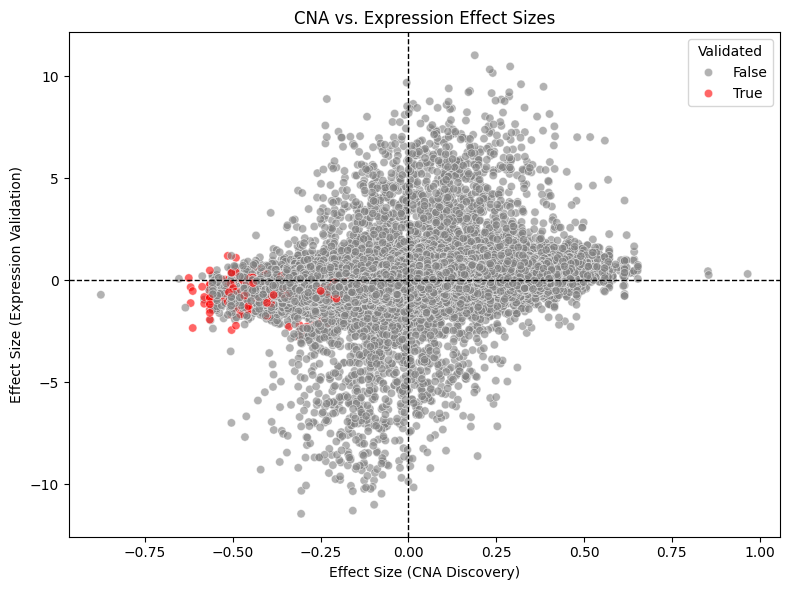

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths – update to where they are saved locally
cna_file = "../results/unified_validation_cna_expr_fdr_removed/cna_screen_unified.csv"
expr_file = "../results/unified_validation_cna_expr_fdr_removed/expression_screen_unified.csv"
val_file = "../results/unified_validation_cna_expr_fdr_removed/validation/validated_pairs.csv"

# Load data
cna_df = pd.read_csv(cna_file)
expr_df = pd.read_csv(expr_file)
val_df = pd.read_csv(val_file)

# Create pair ID for merging (force to string, handle NaNs)
cna_df["Pair"] = cna_df["Biomarker"].astype(str) + "_" + cna_df["TargetGene"].astype(str)
expr_df["Pair"] = expr_df["Biomarker"].astype(str) + "_" + expr_df["TargetGene"].astype(str)
val_df["Pair"] = val_df["Biomarker"].astype(str) + "_" + val_df["TargetGene"].astype(str)


# Merge CNA and expression results
merged = pd.merge(
    cna_df[["Pair", "EffectSize", "P_one_CNA"]],
    expr_df[["Pair", "EffectSize", "P_one"]],
    on="Pair",
    suffixes=("_CNA", "_Expr")
)

merged = merged.rename(columns={
    "P_one_CNA": "P_value_CNA",
    "P_one": "P_value_Expr"
})

# Add validation flag
merged["Validated"] = merged["Pair"].isin(val_df["Pair"])

# Plot 1: Scatterplot of effect sizes
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged,
    x="EffectSize_CNA",
    y="EffectSize_Expr",
    hue="Validated",
    palette={True: "red", False: "grey"},
    alpha=0.6
)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Effect Size (CNA Discovery)")
plt.ylabel("Effect Size (Expression Validation)")
plt.title("CNA vs. Expression Effect Sizes")
plt.legend(title="Validated", loc="best")
plt.tight_layout()
plt.show()

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_1323/296611192.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


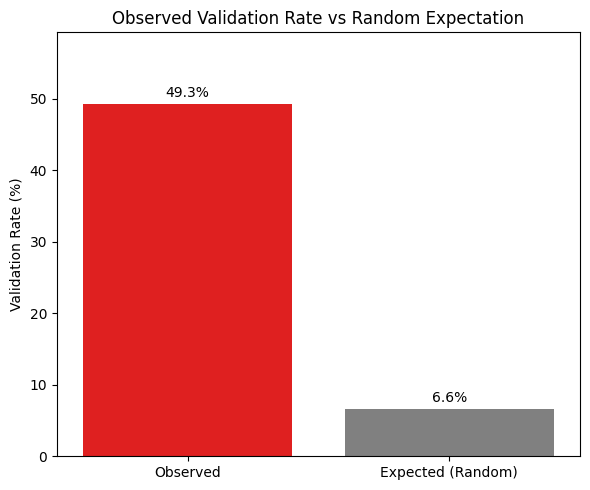

In [51]:
# Plot 2: Bar chart of validation rate vs random
observed_rate = len(val_df) / len(val_df)  # always 1 for your set
total_discovery = cna_df[cna_df["Q_discovery"] <= 0.10]  # or whatever q threshold
observed_rate = len(val_df) / len(total_discovery)

# Expected random rate = proportion of expression hits among all pairs
random_rate = (expr_df["P_one"] < 0.05).mean()

plt.figure(figsize=(6, 5))
sns.barplot(
    x=["Observed", "Expected (Random)"],
    y=[observed_rate * 100, random_rate * 100],
    palette=["red", "grey"]
)
plt.ylabel("Validation Rate (%)")
plt.title("Observed Validation Rate vs Random Expectation")
for i, val in enumerate([observed_rate * 100, random_rate * 100]):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=10)
plt.ylim(0, max(observed_rate * 100, random_rate * 100) + 10)
plt.tight_layout()
plt.show()

### Clean Hits for Agent

In [3]:
import pandas as pd

# Load your full potent hits file
input_file = "../results/overlapping_amp_unified_hits_with_HGNC.csv"
df = pd.read_csv(input_file)

# Extract required columns for the agent
agent_input_df = df[["Biomarker_AMP_HGNC", "TargetGene_AMP_HGNC"]].copy()

# Save for agent use
output_file = "/Users/faith/Desktop/oncosynth/overlapping_gene_pairs.csv"
agent_input_df.to_csv(output_file, index=False)

print(f"Cleaned agent input saved to: {output_file}")

Cleaned agent input saved to: /Users/faith/Desktop/oncosynth/overlapping_gene_pairs.csv


### Getting Chromosomes for Hits

In [5]:
import pandas as pd
from mygene import MyGeneInfo

# Load your file
df = pd.read_csv("../results/overlapping_amp_unified_hits_with_HGNC.csv") 

# Extract first gene symbol from comma-separated lists
df["Biomarker_HGNC_first"] = df["Biomarker_AMP_HGNC"].str.split(",").str[0].str.strip()
df["TargetGene_HGNC_first"] = df["TargetGene_AMP_HGNC"].str.split(",").str[0].str.strip()

# Collect unique gene names to query
genes_to_query = pd.unique(df[["Biomarker_HGNC_first", "TargetGene_HGNC_first"]].values.ravel())

# Query MyGene.info for chromosome info
mg = MyGeneInfo()
query_results = mg.querymany(genes_to_query, scopes="symbol", fields="map_location", species="human", as_dataframe=True)

# Extract and clean chromosome info
chrom_df = query_results.reset_index()[["query", "map_location"]].dropna().drop_duplicates()
chrom_df["Chromosome"] = chrom_df["map_location"].str.extract(r"^(\d+|X|Y)")
chrom_df["Chromosome"] = "chr" + chrom_df["Chromosome"]
chrom_df = chrom_df.rename(columns={"query": "Gene"})

# Merge biomarker chromosome info
df = df.merge(chrom_df.rename(columns={"Gene": "Biomarker_HGNC_first", "Chromosome": "Biomarker_Chr"}), on="Biomarker_HGNC_first", how="left")

# Merge target chromosome info
df = df.merge(chrom_df.rename(columns={"Gene": "TargetGene_HGNC_first", "Chromosome": "TargetGene_Chr"}), on="TargetGene_HGNC_first", how="left")

# Keep only the relevant columns
final_df = df[["Biomarker_AMP_HGNC", "Biomarker_Chr", "TargetGene_AMP_HGNC", "TargetGene_Chr"]]

# Save result
final_df.to_csv("../results/unified_validation_cna_expr_fdr_removed/biomarker_target_chromosomes.csv", index=False)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found no hit:	['MFSD3']
